In [2]:
# os 환경 변수 GEMINI API KEY 입력
import os
from dotenv import load_dotenv

load_dotenv()

True

# Agent 구축 실전 1
https://docs.langchain.com/oss/python/langgraph/thinking-in-langgraph

### 1. Model 및 Tool 정의

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")

### 2. State 정의

In [3]:
from typing_extensions import TypedDict

class AgentState(TypedDict):
    email_content:str
    category:str
    next_step:str
    response:str


### 3. Node 정의

In [4]:
# [Node 1] 이메일 읽기
def read_email(state: AgentState):
    return {'email_content': state['email_content']}

In [5]:
# [Node 2] 의도 분류 (Router 로직의 기준점)
def classify_intent(state: AgentState):
    email = state['email_content']
    if '환불' in email or '긴급' in email or '빨리' in email : 
        category = 'complaint'
        next_step = 'escalate_to_human'
    else : 
        category = 'inquiry'
        next_step = 'search_manual'

    return {'category': category, 'next_step': next_step}

In [6]:
# [Node 3-A] 매뉴얼 검색 (AI 자동 처리 트랙)
def search_manual(state: AgentState):
    print('3-A 진입... 메뉴얼을 검색합니다')
    return 


# [Node 3-B] 상담원 이관 (긴급 이슈 트랙)
def escalate_to_human(state: AgentState):
    print('3-B 진입... 상담원 인관합니다')
    return 


In [7]:
# [Node 4] 답변 생성
def write_reply(state: AgentState):
    email = state['email_content']
    response = model.invoke(email)
    return {'response': response}


### 4. 그래프 생성

In [8]:
from langgraph.graph import StateGraph, START, END

# 1. 워크플로우(그래프) 생성
agent_builder = StateGraph(AgentState)


# 2. 노드(작업자) 배치
agent_builder.add_node('read_email', read_email)
agent_builder.add_node('classify_intent', classify_intent)
agent_builder.add_node('search_manual', search_manual)
agent_builder.add_node('escalate_to_human', escalate_to_human)
agent_builder.add_node('write_reply', write_reply)

# 3. 엣지(연결선) 연결
agent_builder.add_edge(START, 'read_email')
agent_builder.add_edge('read_email', 'classify_intent')

In [9]:
# 라우팅 함수: State의 정보를 보고 어디로 갈지 문자열로 반환
def route_email(state: AgentState):
    if state['next_step'] == 'escalate_to_human':
        return 'escalate_to_human'
    else : 
        return 'search_manual'

In [10]:
# 4. 조건부 엣지 연결
agent_builder.add_conditional_edges(
    'classify_intent', 
    route_email,
    ['escalate_to_human', 'search_manual']
)

In [11]:
# 5. 나머지 엣지(연결선) 연결
agent_builder.add_edge('search_manual', 'write_reply')
agent_builder.add_edge('write_reply', END)
agent_builder.add_edge('escalate_to_human', END)



In [12]:
# 6. 컴파일 (최종 에이전트 생성)
agent = agent_builder.compile()


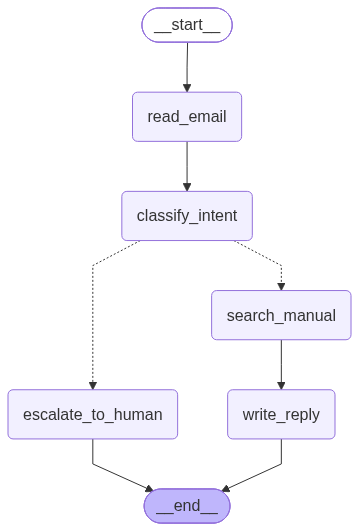

In [13]:
agent

### 실행

In [14]:
inputs = {"email_content": "비밀번호 변경 방법을 알려주세요."}
response = agent.invoke(inputs)

3-A 진입... 메뉴얼을 검색합니다


In [15]:
response

{'email_content': '비밀번호 변경 방법을 알려주세요.',
 'category': 'inquiry',
 'next_step': 'search_manual',
 'response': AIMessage(content=[{'type': 'text', 'text': "비밀번호를 변경하시려는 **서비스나 기기(예: 구글, 네이버, 카카오톡, 윈도우, 인스타그램 등)**가 무엇인지 알려주시면 더 정확한 방법을 안내해 드릴 수 있습니다.\n\n가장 많이 이용하시는 서비스들의 일반적인 변경 방법을 먼저 안내해 드릴게요.\n\n---\n\n### 1. 포털 및 SNS 사이트 (공통적인 방법)\n대부분의 사이트는 비슷한 경로를 통해 비밀번호를 변경할 수 있습니다.\n*   **경로:** [로그인] -> [내 정보] 또는 [설정] -> [보안 설정] -> [비밀번호 변경]\n\n#### **구글 (Google/유튜브)**\n1. 구글 계정에 로그인합니다.\n2. [구글 계정 관리]로 들어갑니다.\n3. 왼쪽 메뉴에서 **[보안]** 탭을 클릭합니다.\n4. 'Google에 로그인하는 방법' 섹션에서 **[비밀번호]**를 클릭합니다.\n5. 현재 비밀번호를 입력한 후 새 비밀번호로 변경합니다.\n\n#### **네이버 (Naver)**\n1. 네이버 로그인 후 내 프로필 옆의 **[내정보]**를 클릭합니다.\n2. 상단 메뉴의 **[보안설정]**을 클릭합니다.\n3. 비밀번호 항목 옆의 **[변경]** 버튼을 누릅니다.\n\n#### **카카오톡 (Kakaotalk)**\n1. 카카오톡 실행 후 **[설정(톱니바퀴)]** -> [전체 설정]으로 들어갑니다.\n2. **[카카오계정]** -> **[계정 보안]**을 누릅니다.\n3. **[비밀번호 변경]**을 선택합니다.\n\n---\n\n### 2. 기기 비밀번호 (PC 및 스마트폰)\n\n#### **윈도우 10/11 (Windows)**\n1. [시작] 버튼 -> **[설정(톱니바퀴)]**를 클릭합니다.\n2. **

In [16]:
inputs = {"email_content": "당장 환불해줘!"}
response = agent.invoke(inputs)

3-B 진입... 상담원 인관합니다


In [17]:
response

{'email_content': '당장 환불해줘!',
 'category': 'complaint',
 'next_step': 'escalate_to_human'}

In [18]:
inputs = {"email_content": "당장 환급해줘!"}
response = agent.invoke(inputs)

3-A 진입... 메뉴얼을 검색합니다


In [19]:
response

{'email_content': '당장 환급해줘!',
 'category': 'inquiry',
 'next_step': 'search_manual',
 'response': AIMessage(content=[{'type': 'text', 'text': "환급 문제로 많이 답답하고 화가 나신 상황이시군요.\n\n하지만 안타깝게도 **저는 인공지능 어시스턴트이기 때문에 사용자의 결제 내역을 확인하거나 직접 환급(환불)을 처리할 수 있는 권한이 없습니다.**\n\n어떤 서비스나 제품에 대해 환불을 원하시는지 알려주시면, **어떻게 환불 신청을 해야 하는지 구체적인 방법**을 안내해 드릴 수 있습니다.\n\n일반적으로 환불을 받으려면 다음 단계가 필요합니다.\n\n1.  **해당 서비스 고객센터에 연락:** 앱이나 사이트 내의 [마이페이지] -> [고객센터] 또는 [1:1 문의]를 이용하세요.\n2.  **결제 수단 확인:** 신용카드, 계좌이체, 휴대폰 결제 등 어떤 수단으로 결제했는지 확인이 필요합니다.\n3.  **구글 플레이스토어/애플 앱스토어 결제인 경우:**\n    *   **구글:** 'Google Play 고객센터'에서 환불 요청\n    *   **애플:** 'reportaproblem.apple.com'에 접속하여 환불 요청\n\n**어디에서 결제하신 건가요? (예: 쿠팡, 네이버쇼핑, 유튜브 프리미엄, 게임 아이템 등)** \n알려주시면 바로 찾아볼 수 있는 링크나 연락처를 확인해 드리겠습니다.", 'extras': {'signature': 'EpIQCo8QARFNMg8GuYbcIGRYlemN5qjmCO6fZ63vDdq+qUxdRFfzKQWXEGNSV4C+i8gABjsSXDhHxhKQQbY9tZB6YYpNEp2v0obmKcYSWNm+z/pOAOxKwQQQwT0+UyV2qYlewhzb7kKKPjaXVpCCXgFkgjgxIE7gH13RsZxTCQ3U0YIFdczTmB87jg9HYyU5ed/OSpsk5wp3dDZF6N6PHew6hr/VCacPPaRe

# Agent 구축 실전 2

### 1. Model 및 Tool 정의

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")

In [4]:
from langchain.tools import tool

@tool
def search_manual(query: str) -> str:
    """
    고객의 질문에 답변하기 위해 참고할만한 규정이나 메뉴얼을 검색할 때 사용하는 도구
    """
    if '비밀번호' in query :
        return '비밀번호 변경은 마이페이지 - 보안 설정에 있음'
    elif '배송' in query : 
        return '00택배에서 3일 내 배송 예정임'
    else : 
        return '해당 내용 관련 메뉴얼은 찾을 수 없습니다'


/Users/dohyunkim/Documents/langchain-study/langgraph/.venv/lib/python3.13/site-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [5]:
tools = [search_manual]

In [6]:
model_with_tools = model.bind_tools(tools)

### 2. State 정의

In [8]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages : Annotated[list[AnyMessage], add_messages]
    next_step : str 



### 3. Node 정의

In [9]:
# [Node 1] 분류 노드 (Manager)
# LLM에게 이메일을 읽고 어떤 트랙으로 보낼지 결정
from langchain.messages import SystemMessage


def classify_node(state: AgentState):
    print("\n--- [1] 분류 단계 (LLM 판단) ---")
    last_message = state["messages"][-1] # human message

    # 분류를 위한 프롬프트 (System Prompt)
    prompt = """
    당신은 고객 센터 관리자입니다. 고객의 이메일을 분석해서 다음 단계를 결정하세요.

    1. 단순 문의나 정보 요청이라면 -> 'consultant' 반환
    2. 환불 요청, 불만 제기, 화난 고객이라면 -> 'escalate' 반환

    답변은 오직 단어 하나만 하세요.
    """

    # LLM 호출
    response = model.invoke([SystemMessage(content=prompt)] + last_message)
    raw_content = response.content


    if isinstance(raw_content, list):
        # Gemini 등: 리스트로 오는 경우 텍스트 블록만 추출해서 합침
        decision = "".join([block['text'] for block in raw_content if block.get('type') == 'text'])
    else:
        # OpenAI 등: 문자열로 오는 경우 그대로 사용
        decision = str(raw_content)

    # 공백 제거 및 소문자 변환
    decision = decision.strip().lower()
    print(f"   -> LLM 판단 결과: {decision}")

    # 다음 단계(next_step)를 상태에 저장
    if "escalate" in decision:
        return {"next_step": "escalate"}
    else:
        return {"next_step": "consultant"}

In [11]:
# [Node 2] 상담 AI 노드 (Worker)
# 도구를 사용해서 답변을 생성하는 실제 에이전트
def consultant_node(state: AgentState):
    print("\n--- [2-A] 상담 AI 답변 생성 중 ---")
    response = model_with_tools.invoke(state['messages'])
    return {'messages': [response]}
    


In [12]:
from langchain_core.messages import AIMessage

# [Node 3] 상담원 이관 노드
def escalate_node(state: AgentState):
    return {'messages': [AIMessage(content='해당 메일은 전문 상담원에게 이관되었습니다.')]}


In [13]:
tools = [search_manual]

In [14]:
tools

[StructuredTool(name='search_manual', description='고객의 질문에 답변하기 위해 참고할만한 규정이나 메뉴얼을 검색할 때 사용하는 도구', args_schema=<class 'langchain_core.utils.pydantic.search_manual'>, func=<function search_manual at 0x112082200>)]

In [15]:
tools_by_name = {tool.name: tool for tool in tools}

In [16]:
tools_by_name

{'search_manual': StructuredTool(name='search_manual', description='고객의 질문에 답변하기 위해 참고할만한 규정이나 메뉴얼을 검색할 때 사용하는 도구', args_schema=<class 'langchain_core.utils.pydantic.search_manual'>, func=<function search_manual at 0x112082200>)}

In [17]:
from langchain.messages import ToolMessage
# [Node 4] Tool Node
def tool_node(state: AgentState):
    print("\n--- [Tool Node] 도구 직접 실행 ---")
    result = []
    # 가장 최근 메시지에서 도구 호출 요청 꺼내기
    last_message = state["messages"][-1]

    for tool_call in last_message.tool_calls:
        # 1. 도구 이름으로 실제 함수 찾기
        tool = tools_by_name[tool_call["name"]]

        # 2. 함수를 실행하여 결과를 얻기
        print(f"   -> 실행 중: {tool_call['name']}")
        tool_result = tool.invoke(tool_call["args"])

        # 3. 결과를 ToolMessage 형태로 포장 (tool_call_id 필수!)
        result.append(ToolMessage(content=str(tool_result), tool_call_id=tool_call["id"]))

    # 실행 결과를 대화 기록에 추가
    return {"messages": result}

### 4. 그래프 생성

In [18]:
from langgraph.graph import StateGraph, START, END

# 1. 워크플로우(그래프) 생성
agent_builder = StateGraph(AgentState)


# 2. 노드(작업자) 배치
agent_builder.add_node('classify_node', classify_node)
agent_builder.add_node('consultant_node', consultant_node)
agent_builder.add_node('escalate_node', escalate_node)
agent_builder.add_node('tool_node', tool_node)


# 3. 엣지(연결선) 연결
agent_builder.add_edge(START, 'classify_node')


In [19]:
# 라우터 1: 분류 결과에 따른 분기
def route_after_classify(state: AgentState):
    if state['next_step'] == 'escalate' : 
        return 'escalate'
    else : 
        return 'consultant'


In [20]:
# 라우터 2: 도구 사용 여부 판단
def should_continue(state: AgentState):
    last_message = state["messages"][-1]

    # LLM이 도구 호출(tool_calls)을 포함한 응답을 보낸 경우
    if last_message.tool_calls:
        return "tool_node"

    # 도구 호출이 없으면 종료
    return END

In [21]:
# 4. 조건부 엣지 연결
agent_builder.add_conditional_edges(    
    'classify_node',
    route_after_classify,
    {
        'escalate': 'escalate_node',
        'consultant': 'consultant_node'
    }

)

In [22]:
# 상담 AI 후 도구 사용 여부 판단
agent_builder.add_conditional_edges(
    'consultant_node',
    should_continue,
    ['tool_node', END]

)

In [23]:
# 5. 나머지 엣지(연결선) 연결

agent_builder.add_edge('tool_node', 'consultant_node')
agent_builder.add_edge('escalate_node', END)

In [ ]:
# 6. 컴파일 (최종 에이전트 생성)
agent = agent_builder.compile()

In [ ]:
agent

### 실행

In [ ]:
from langchain.messages import HumanMessage, SystemMessage

inputs = {"messages": [HumanMessage(content="비밀번호 변경은 어디서 해?")]}
response = agent.invoke(inputs)

In [ ]:
response

In [ ]:
response["messages"][-1].content[-1]['text']

In [ ]:
inputs = {"messages": [HumanMessage(content="당장 환불해줘!")]}
response = agent.invoke(inputs)

In [ ]:
response

#### State 설계 원칙
([공식 문서](https://docs.langchain.com/oss/python/langgraph/thinking-in-langgraph#what-belongs-in-state))